In [2]:
from google.cloud import bigquery

client = bigquery.Client.from_service_account_json(
    "../credentials/service_account.json"
)

print("Conexión exitosa")

Conexión exitosa


In [3]:
from google.cloud import bigquery

# Borramos la línea que sobreescribía el cliente. 
# Jupyter ya recuerda la variable 'client' que creaste y autenticaste en la celda [2].

# Guardamos todo tu SQL en una variable de texto (string)
query = """
CREATE SCHEMA IF NOT EXISTS retail_dw;

CREATE TABLE IF NOT EXISTS retail_dw.clientes (
    id_cliente INT64,
    nombre STRING,
    pais STRING
);

CREATE TABLE IF NOT EXISTS retail_dw.productos (
    id_producto INT64,
    producto STRING,
    categoria STRING
);

CREATE TABLE IF NOT EXISTS retail_dw.ventas (
    id_venta INT64,
    fecha_venta DATE,
    id_cliente INT64,
    id_producto INT64,
    sucursal STRING,
    monto NUMERIC
);
"""

# Ejecutamos el query usando el 'client' de la celda [2]
job = client.query(query)
job.result()

print("¡Esquema y tablas creados con éxito en BigQuery!")

¡Esquema y tablas creados con éxito en BigQuery!


In [4]:
import pandas as pd
import random
import os
from faker import Faker
from datetime import datetime, timedelta

# Inicializamos Faker
fake = Faker('es_MX')

# Asegurar que el directorio de salida exista
output_dir = '../datasets'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"Iniciando la generación de datos en la carpeta: {output_dir}/")

# 1. Generar 5,000 Clientes
print("Generando clientes.csv...")
paises_operacion = ['Guatemala', 'El Salvador', 'Honduras', 'Costa Rica']
clientes_data = []

for i in range(1, 5001):
    clientes_data.append({
        'id_cliente': i,
        'nombre': fake.name(),
        'pais': random.choice(paises_operacion)
    })

df_clientes = pd.DataFrame(clientes_data)
df_clientes.to_csv(os.path.join(output_dir, 'clientes.csv'), index=False)

# 2. Generar 500 Productos
print("Generando productos.csv...")
categorias = ['Electrónica', 'Hogar', 'Ropa', 'Deportes', 'Alimentos']
productos_data = []

for i in range(1, 501):
    productos_data.append({
        'id_producto': i,
        'producto': f'Producto_SKU_{i}', 
        'categoria': random.choice(categorias)
    })

df_productos = pd.DataFrame(productos_data)
df_productos.to_csv(os.path.join(output_dir, 'productos.csv'), index=False)

# 3. Generar 100,000 Ventas
print("Generando ventas.csv...")
sucursales_dict = {
    'Guatemala': ['Sucursal_GUA_Centro', 'Sucursal_GUA_Norte'],
    'El Salvador': ['Sucursal_ESV_San_Salvador', 'Sucursal_ESV_Santa_Ana'],
    'Honduras': ['Sucursal_HON_Tegucigalpa'],
    'Costa Rica': ['Sucursal_CRI_San_Jose', 'Sucursal_CRI_Alajuela']
}

ventas_data = []
start_date = datetime(2023, 1, 1)
end_date = datetime(2026, 6, 17)

for i in range(1, 100001):
    cliente = random.choice(clientes_data)
    sucursal = random.choice(sucursales_dict[cliente['pais']])
    random_days = random.randint(0, (end_date - start_date).days)
    fecha_venta = start_date + timedelta(days=random_days)
    
    ventas_data.append({
        'id_venta': i,
        'fecha_venta': fecha_venta.strftime('%Y-%m-%d'),
        'id_cliente': cliente['id_cliente'],
        'id_producto': random.randint(1, 500),
        'sucursal': sucursal,
        'monto': round(random.uniform(50.0, 5000.0), 2)
    })

df_ventas = pd.DataFrame(ventas_data)
df_ventas.to_csv(os.path.join(output_dir, 'ventas.csv'), index=False)

print(f"¡Proceso finalizado! Los archivos están listos en: {output_dir}/")

Iniciando la generación de datos en la carpeta: ../datasets/
Generando clientes.csv...
Generando productos.csv...
Generando ventas.csv...
¡Proceso finalizado! Los archivos están listos en: ../datasets/


In [5]:
from google.cloud import bigquery
import os

# Configuración inicial
dataset_id = 'retail_dw'

# Lista de archivos a cargar y sus tablas destino
archivos_a_cargar = {
    'clientes.csv': 'clientes',
    'productos.csv': 'productos',
    'ventas.csv': 'ventas'
}

# Configuración del job de carga
# Configuración del job de carga
job_config = bigquery.LoadJobConfig(
    source_format=bigquery.SourceFormat.CSV,
    skip_leading_rows=1,  # Saltamos el encabezado del CSV
    autodetect=False,     # <-- APAGAMOS el autodetect para que respete nuestro esquema
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE # <-- Reemplaza los datos si ya existen, evitando duplicados
)

for archivo, tabla in archivos_a_cargar.items():
    # El '..' le dice a Python: "Sube una carpeta, luego entra a 'datasets' y busca el archivo"
    ruta_archivo = os.path.join('..', 'datasets', archivo)
    table_ref = f"{client.project}.{dataset_id}.{tabla}"
    
    print(f"Cargando {archivo} a {table_ref}...")
    
    with open(ruta_archivo, "rb") as source_file:
        job = client.load_table_from_file(source_file, table_ref, job_config=job_config)
    
    job.result()  # Esperamos a que la carga finalice
    
    table = client.get_table(table_ref)
    print(f"Carga completada. Total de filas en {tabla}: {table.num_rows}")

Cargando clientes.csv a project-e5dd6fd9-f250-4d97-810.retail_dw.clientes...
Carga completada. Total de filas en clientes: 5000
Cargando productos.csv a project-e5dd6fd9-f250-4d97-810.retail_dw.productos...
Carga completada. Total de filas en productos: 500
Cargando ventas.csv a project-e5dd6fd9-f250-4d97-810.retail_dw.ventas...
Carga completada. Total de filas en ventas: 100000


In [7]:
# ---------------------------------------------------------
# 1. Top 10 Productos
# ---------------------------------------------------------
print("--- 1. Top 10 Productos más vendidos ---")
query_top_productos = """
SELECT
    p.producto,
    SUM(v.monto) as total_ventas
FROM retail_dw.ventas v
JOIN retail_dw.productos p
ON v.id_producto = p.id_producto
GROUP BY p.producto
ORDER BY total_ventas DESC
LIMIT 10;
"""
# Ejecutamos la consulta y la mostramos
df_top_productos = client.query(query_top_productos).to_dataframe()
display(df_top_productos)


# ---------------------------------------------------------
# 2. Ventas por País
# ---------------------------------------------------------
print("\n--- 2. Ventas totales por País ---")
query_ventas_pais = """
SELECT
    c.pais,
    SUM(v.monto) as total_ventas
FROM retail_dw.ventas v
JOIN retail_dw.clientes c
ON v.id_cliente = c.id_cliente
GROUP BY c.pais
ORDER BY total_ventas DESC;
"""
df_ventas_pais = client.query(query_ventas_pais).to_dataframe()
display(df_ventas_pais)


# ---------------------------------------------------------
# 3. Ventas Mensuales
# ---------------------------------------------------------
print("\n--- 3. Tendencia de Ventas Mensuales ---")
query_ventas_mensuales = """
SELECT
    EXTRACT(MONTH FROM fecha_venta) as mes,
    SUM(monto) as ventas
FROM retail_dw.ventas
GROUP BY mes
ORDER BY mes;
"""
df_ventas_mensuales = client.query(query_ventas_mensuales).to_dataframe()
display(df_ventas_mensuales)

--- 1. Top 10 Productos más vendidos ---


C:\Users\jrodr\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,producto,total_ventas
0,Producto_SKU_58,647996.590000000
1,Producto_SKU_297,623671.890000000
2,Producto_SKU_494,618042.230000000
3,Producto_SKU_32,616948.010000000
4,Producto_SKU_348,616779.540000000
5,Producto_SKU_423,613094.720000000
6,Producto_SKU_412,608892.250000000
7,Producto_SKU_375,608057.030000000
8,Producto_SKU_359,603492.620000000
9,Producto_SKU_219,603200.840000000



--- 2. Ventas totales por País ---


C:\Users\jrodr\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,pais,total_ventas
0,Honduras,66085503.660000000
1,Costa Rica,63877691.980000000
2,Guatemala,62120601.560000000
3,El Salvador,61069327.230000000



--- 3. Tendencia de Ventas Mensuales ---


C:\Users\jrodr\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,mes,ventas
0,1,24689072.690000000
1,2,22351028.620000000
2,3,25136257.980000000
3,4,24026984.080000000
4,5,24883652.780000000
5,6,21381127.910000000
6,7,18684554.270000000
7,8,18799530.540000000
8,9,17956949.170000000
9,10,18886226.050000000


In [9]:
from google.cloud import bigquery
import time

# Asumiendo que tu cliente ya está inicializado
# client = bigquery.Client()

# ---------------------------------------------------------
# 1. Crear Tablas Optimizadas en BigQuery
# ---------------------------------------------------------
print("Creando tabla particionada por fecha...")
query_particionada = """
CREATE OR REPLACE TABLE retail_dw.ventas_particionadas
PARTITION BY fecha_venta
AS SELECT * FROM retail_dw.ventas;
"""
client.query(query_particionada).result()

print("Creando tabla particionada y clusterizada por sucursal...")
query_cluster = """
CREATE OR REPLACE TABLE retail_dw.ventas_cluster
PARTITION BY fecha_venta
CLUSTER BY sucursal
AS SELECT * FROM retail_dw.ventas;
"""
client.query(query_cluster).result()

print("\n¡Tablas optimizadas creadas exitosamente!\n")

# ---------------------------------------------------------
# 2. Comparación de Rendimiento, Costo y Tiempo
# ---------------------------------------------------------
def comparar_rendimiento(tabla, descripcion):
    # Simulamos buscar las ventas de un día específico y una sucursal específica
    query = f"""
    SELECT * FROM retail_dw.{tabla} 
    WHERE fecha_venta = '2025-06-15' 
    AND sucursal = 'Sucursal_GUA_Centro'
    """
    
    # IMPORTANTE: 
    # dry_run=False para que se ejecute y podamos medir el tiempo.
    # use_query_cache=False asegura que BigQuery procese los datos desde cero cada vez.
    job_config = bigquery.QueryJobConfig(use_query_cache=False)
    
    # Medir el tiempo de inicio
    start_time = time.time()
    
    # Ejecutamos la consulta y esperamos el resultado
    query_job = client.query(query, job_config=job_config)
    query_job.result() 
    
    # Medir el tiempo de finalización
    end_time = time.time()
    tiempo_ejecucion = end_time - start_time
    
    # Extraer métricas clave de la API de BigQuery
    mb_procesados = query_job.total_bytes_processed / (1024 * 1024)
    mb_facturados = query_job.total_bytes_billed / (1024 * 1024) if query_job.total_bytes_billed else 0
    slot_millis = query_job.slot_millis if query_job.slot_millis else 0
    
    # Retornamos un diccionario con los resultados
    return {
        "Tabla": descripcion,
        "MB Procesados": round(mb_procesados, 2),
        "MB Facturados": round(mb_facturados, 2),
        "Tiempo (seg)": round(tiempo_ejecucion, 3),
        "Slot ms (CPU)": slot_millis
    }

print("Ejecutando consultas de prueba (esto puede tomar unos segundos)...\n")

# Recopilamos los resultados en una lista
resultados = [
    comparar_rendimiento("ventas", "1. Original (Sin Optimización)"),
    comparar_rendimiento("ventas_particionadas", "2. Particionada (Por fecha)"),
    comparar_rendimiento("ventas_cluster", "3. Particionada + Clusterizada")
]

# ---------------------------------------------------------
# 3. Imprimir Resultados en una Tabla Profesional
# ---------------------------------------------------------
# Definimos el ancho de las columnas para la tabla
col_w = [35, 15, 15, 15, 15]

# Imprimir el encabezado de la tabla
header = f"| {'Tipo de Tabla'.ljust(col_w[0])} | {'MB Procesados'.rjust(col_w[1])} | {'MB Facturados'.rjust(col_w[2])} | {'Tiempo (seg)'.rjust(col_w[3])} | {'Slot ms (CPU)'.rjust(col_w[4])} |"
separador = "-" * len(header)

print(separador)
print(header)
print(separador)

# Imprimir cada fila de resultados
for r in resultados:
    fila = f"| {r['Tabla'].ljust(col_w[0])} | {str(r['MB Procesados']).rjust(col_w[1])} | {str(r['MB Facturados']).rjust(col_w[2])} | {str(r['Tiempo (seg)']).rjust(col_w[3])} | {str(r['Slot ms (CPU)']).rjust(col_w[4])} |"
    print(fila)

print(separador)
print("\n* Nota: 'Slot ms' representa el esfuerzo computacional total utilizado por BigQuery.")

Creando tabla particionada por fecha...
Creando tabla particionada y clusterizada por sucursal...

¡Tablas optimizadas creadas exitosamente!

Ejecutando consultas de prueba (esto puede tomar unos segundos)...

---------------------------------------------------------------------------------------------------------------
| Tipo de Tabla                       |   MB Procesados |   MB Facturados |    Tiempo (seg) |   Slot ms (CPU) |
---------------------------------------------------------------------------------------------------------------
| 1. Original (Sin Optimización)      |            6.84 |            10.0 |           0.822 |              50 |
| 2. Particionada (Por fecha)         |             0.0 |            10.0 |           0.896 |              41 |
| 3. Particionada + Clusterizada      |             0.0 |            10.0 |           0.916 |              18 |
---------------------------------------------------------------------------------------------------------------

* Not

In [ ]:
!pip install db-dtypes

In [9]:
# ---------------------------------------------------------
# Parte 10: Crear Vista Materializada
# ---------------------------------------------------------
print("Creando Vista Materializada 'mv_ventas_producto'...")

query_mv = """
CREATE MATERIALIZED VIEW IF NOT EXISTS retail_dw.mv_ventas_producto AS
SELECT
    id_producto,
    SUM(monto) as total_ventas
FROM retail_dw.ventas
GROUP BY id_producto;
"""

# Ejecutamos la creación de la vista
client.query(query_mv).result()
print("¡Vista Materializada creada exitosamente!")

# ---------------------------------------------------------
# Verificar los datos precalculados
# ---------------------------------------------------------
print("\n--- Consultando la Vista Materializada (Top 5 preliminar) ---")
query_test_mv = """
SELECT * FROM retail_dw.mv_ventas_producto
ORDER BY total_ventas DESC
LIMIT 5;
"""

# Convertimos a DataFrame para visualizarlo bonito en el notebook
df_mv = client.query(query_test_mv).to_dataframe()
display(df_mv)

Creando Vista Materializada 'mv_ventas_producto'...
¡Vista Materializada creada exitosamente!

--- Consultando la Vista Materializada (Top 5 preliminar) ---


C:\Users\jrodr\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id_producto,total_ventas
0,58,647996.590000000
1,297,623671.890000000
2,494,618042.230000000
3,32,616948.010000000
4,348,616779.540000000


Generando Dashboard Exploratorio a partir de tablas optimizadas...


C:\Users\jrodr\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


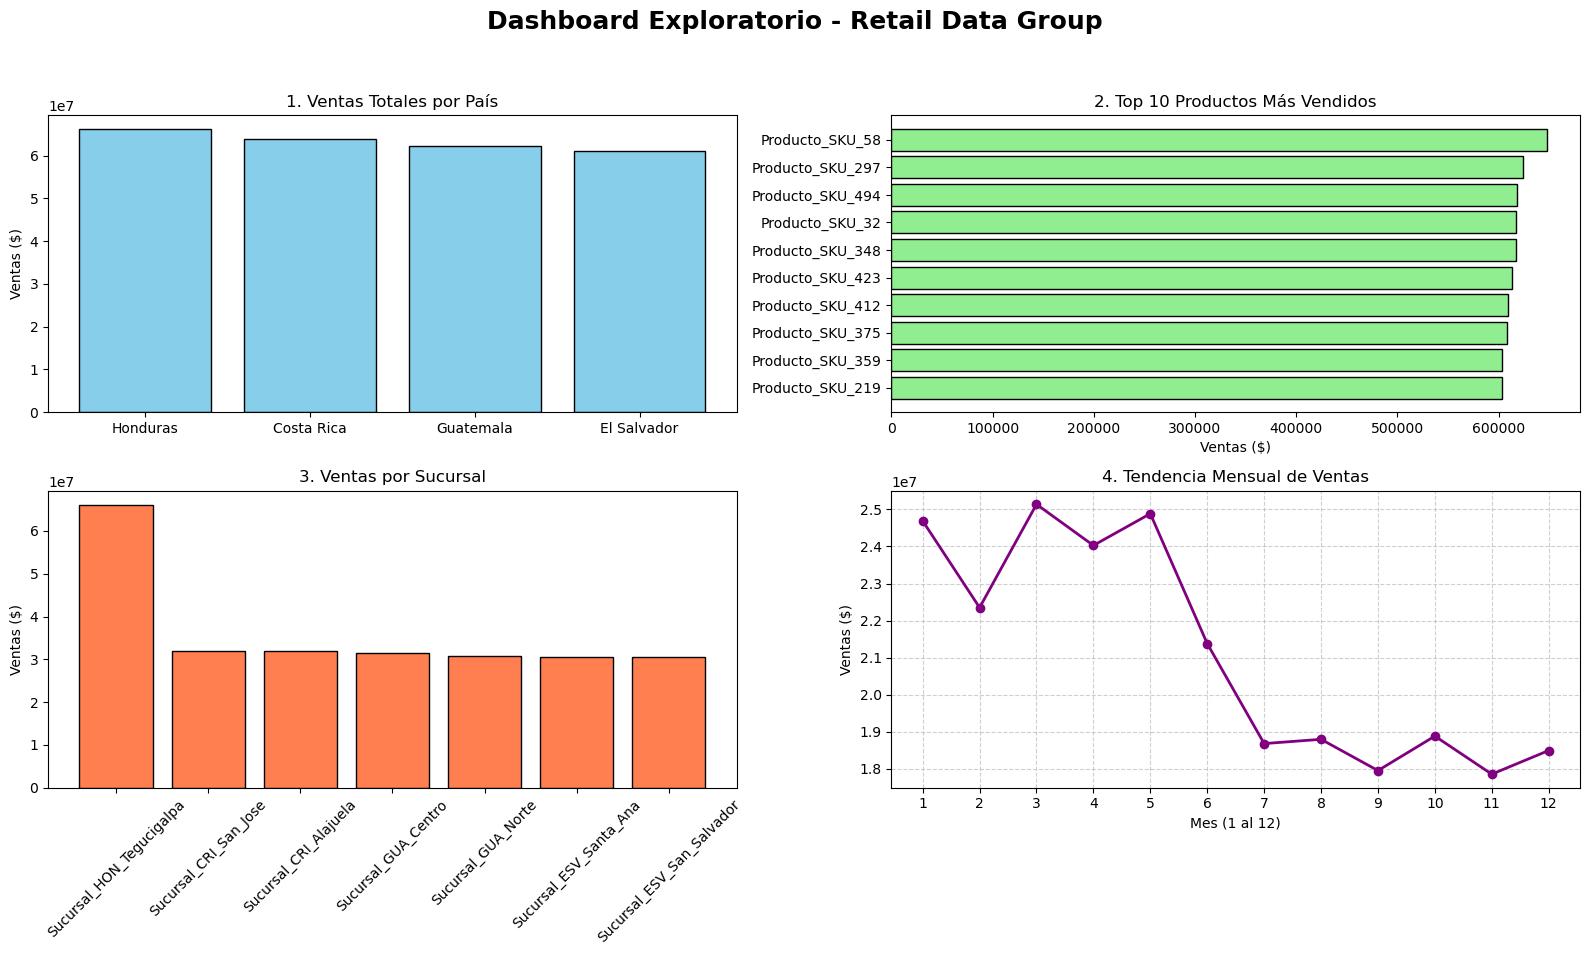

In [10]:
# ---------------------------------------------------------
# Parte 11: Dashboard Exploratorio en Python
# ---------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

print("Generando Dashboard Exploratorio a partir de tablas optimizadas...")

# Configuración de la figura principal (2 filas, 2 columnas)
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Dashboard Exploratorio - Retail Data Group', fontsize=18, fontweight='bold')

# 1. Ventas por País (Usamos la tabla Clusterizada)
query_pais = """
SELECT c.pais, SUM(v.monto) as total_ventas
FROM retail_dw.ventas_cluster v
JOIN retail_dw.clientes c ON v.id_cliente = c.id_cliente
GROUP BY c.pais
ORDER BY total_ventas DESC;
"""
df_pais = client.query(query_pais).to_dataframe()
axs[0, 0].bar(df_pais['pais'], df_pais['total_ventas'], color='skyblue', edgecolor='black')
axs[0, 0].set_title('1. Ventas Totales por País')
axs[0, 0].set_ylabel('Ventas ($)')

# 2. Top 10 Productos (Usamos la VISTA MATERIALIZADA de la Parte 10)
query_productos = """
SELECT p.producto, mv.total_ventas
FROM retail_dw.mv_ventas_producto mv
JOIN retail_dw.productos p ON mv.id_producto = p.id_producto
ORDER BY total_ventas DESC
LIMIT 10;
"""
df_prod = client.query(query_productos).to_dataframe()
axs[0, 1].barh(df_prod['producto'], df_prod['total_ventas'], color='lightgreen', edgecolor='black')
axs[0, 1].set_title('2. Top 10 Productos Más Vendidos')
axs[0, 1].set_xlabel('Ventas ($)')
axs[0, 1].invert_yaxis() # Invertimos para que el #1 salga arriba

# 3. Ventas por Sucursal (Usamos la tabla Clusterizada)
query_sucursal = """
SELECT sucursal, SUM(monto) as total_ventas
FROM retail_dw.ventas_cluster
GROUP BY sucursal
ORDER BY total_ventas DESC;
"""
df_sucursal = client.query(query_sucursal).to_dataframe()
axs[1, 0].bar(df_sucursal['sucursal'], df_sucursal['total_ventas'], color='coral', edgecolor='black')
axs[1, 0].set_title('3. Ventas por Sucursal')
axs[1, 0].set_ylabel('Ventas ($)')
axs[1, 0].tick_params(axis='x', rotation=45) # Rotamos los textos para que se lean bien

# 4. Tendencia Mensual (Usamos la tabla Particionada)
query_tendencia = """
SELECT EXTRACT(MONTH FROM fecha_venta) as mes, SUM(monto) as total_ventas
FROM retail_dw.ventas_particionadas
GROUP BY mes
ORDER BY mes;
"""
df_tendencia = client.query(query_tendencia).to_dataframe()
axs[1, 1].plot(df_tendencia['mes'], df_tendencia['total_ventas'], marker='o', linestyle='-', color='purple', linewidth=2)
axs[1, 1].set_title('4. Tendencia Mensual de Ventas')
axs[1, 1].set_xlabel('Mes (1 al 12)')
axs[1, 1].set_ylabel('Ventas ($)')
axs[1, 1].set_xticks(range(1, 13))
axs[1, 1].grid(True, linestyle='--', alpha=0.6)

# Ajuste automático de espacios y mostrar gráfico
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()